Fitting Incremental PCA...
Chunk 0 processed for PCA, RAM usage: 75.2%
Chunk 1 processed for PCA, RAM usage: 75.4%
Chunk 2 processed for PCA, RAM usage: 75.4%
Chunk 3 processed for PCA, RAM usage: 75.4%
Chunk 4 processed for PCA, RAM usage: 75.4%
Chunk 5 processed for PCA, RAM usage: 75.4%
Chunk 6 processed for PCA, RAM usage: 75.4%
Chunk 7 processed for PCA, RAM usage: 75.4%
Chunk 8 processed for PCA, RAM usage: 75.4%
Chunk 9 processed for PCA, RAM usage: 75.4%
Chunk 10 processed for PCA, RAM usage: 75.4%
Chunk 11 processed for PCA, RAM usage: 75.4%
Chunk 12 processed for PCA, RAM usage: 75.4%
Chunk 13 processed for PCA, RAM usage: 75.3%
Chunk 14 processed for PCA, RAM usage: 75.4%
Chunk 15 processed for PCA, RAM usage: 75.4%
Chunk 16 processed for PCA, RAM usage: 75.4%
Chunk 17 processed for PCA, RAM usage: 75.4%
Chunk 18 processed for PCA, RAM usage: 75.4%
Chunk 19 processed for PCA, RAM usage: 75.4%
Chunk 20 processed for PCA, RAM usage: 75.4%
Chunk 21 processed for PCA, RAM usage:

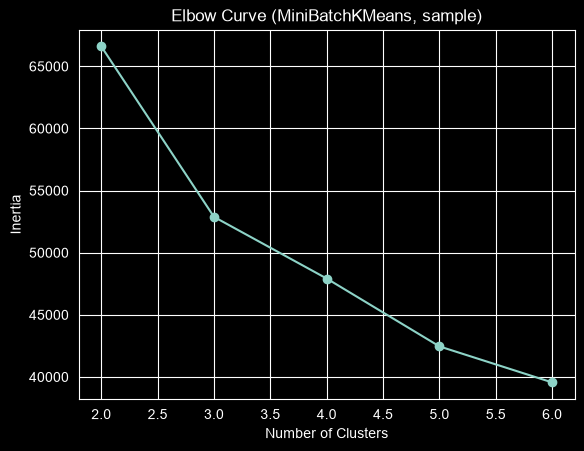

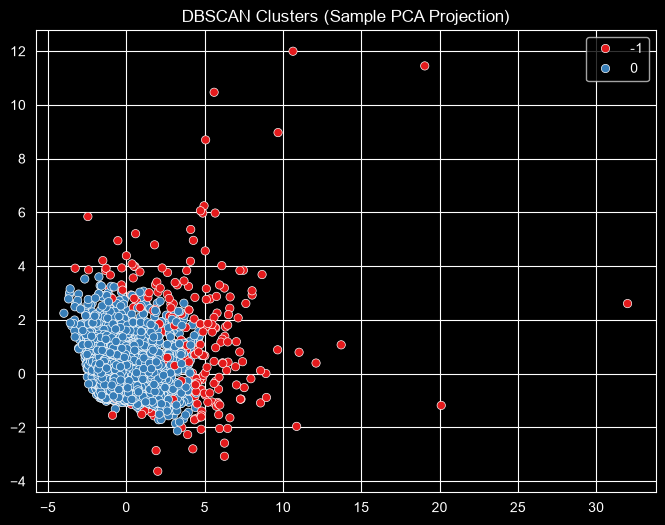

C:\Users\cxsha\PycharmProjects\Telangana_govt_ration_distribution_analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


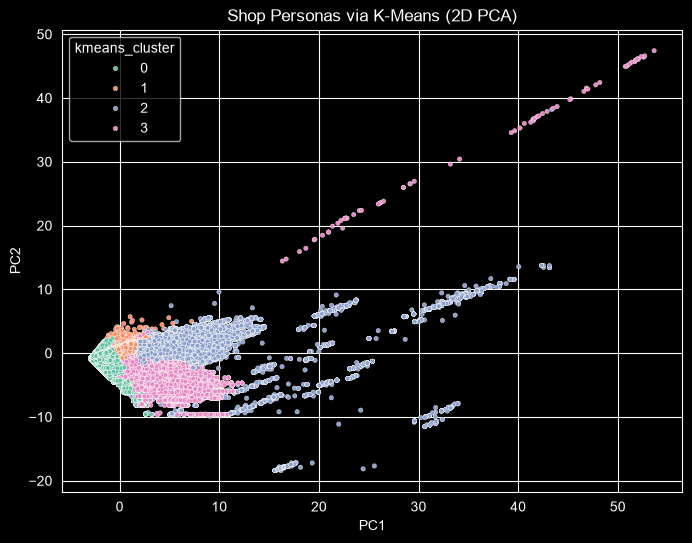

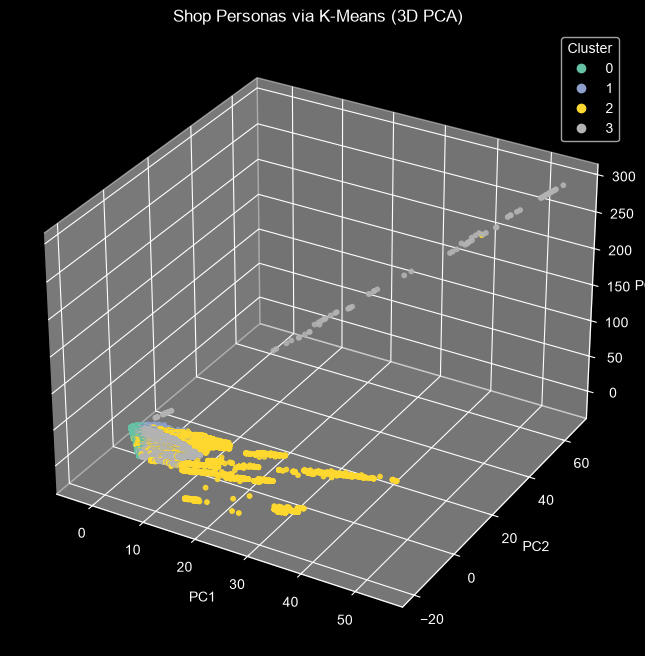

Cluster Profiles:
                 utilization_ratio  rice_wheat_ratio  trans_volatility  \
kmeans_cluster                                                          
0                        0.746640       5233.934124         21.557174   
1                        0.885723      10415.475840         27.235871   
2                        1.076464      20050.534562         85.447825   
3                        1.125182       1440.077296        107.276656   

                 lag_trans  rolling_mean_3m  onor_policy  
kmeans_cluster                                            
0               273.616990       272.226788          1.0  
1               528.717720       527.458074          1.0  
2               984.353825       982.663024          1.0  
3               994.525889       992.200286          1.0  

Behavioral Personas:
Cluster 0: High Utilization Shops – consistently high usage, stable transactions
Cluster 1: Mixed Grain Shops – balanced rice/wheat ratio, moderate volatility
Cluster

In [2]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psutil

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import IncrementalPCA
from sklearn.cluster import MiniBatchKMeans, DBSCAN
from sklearn.metrics import silhouette_score

# --- Parameters ---
meta_cols = ["distCode","distName_x","year","shopNo","longitude","latitude"]
feature_cols = ["utilization_ratio","rice_wheat_ratio","trans_volatility",
                "lag_trans","rolling_mean_3m","onor_policy"]

use_cols = meta_cols + feature_cols
chunk_size = 50000
n_components = 5
n_clusters = 4

# --- Initialize Models ---
scaler = StandardScaler()
ipca = IncrementalPCA(n_components=n_components, batch_size=chunk_size)
mbk = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, batch_size=1000)

# --- First Pass: Fit PCA incrementally ---
print("Fitting Incremental PCA...")
for i, chunk in enumerate(pd.read_csv(
    "..//data//engineered_features.csv",
    usecols=use_cols, chunksize=chunk_size, low_memory=False)):

    chunk = chunk.fillna(0)
    X_scaled = scaler.fit_transform(chunk[feature_cols])   # only numeric features
    ipca.partial_fit(X_scaled)
    print(f"Chunk {i} processed for PCA, RAM usage: {psutil.virtual_memory().percent}%")

# --- Second Pass: Transform + Cluster incrementally ---
results = []
print("Clustering with MiniBatchKMeans...")
for i, chunk in enumerate(pd.read_csv(
    "..//data//engineered_features.csv",
    usecols=use_cols, chunksize=chunk_size, low_memory=False)):

    chunk = chunk.fillna(0)
    X_scaled = scaler.fit_transform(chunk[feature_cols])
    X_reduced = ipca.transform(X_scaled)
    labels = mbk.partial_fit(X_reduced).predict(X_reduced)
    chunk["kmeans_cluster"] = labels
    results.append(chunk)
    print(f"Chunk {i} clustered, RAM usage: {psutil.virtual_memory().percent}%")

# --- Combine Results Safely ---
df_clusters = pd.concat(results, ignore_index=True)

# --- Evaluate with Silhouette Score (sample) ---
sample_idx = np.random.choice(len(df_clusters), size=5000, replace=False)
X_sample = ipca.transform(scaler.fit_transform(df_clusters[feature_cols].iloc[sample_idx]))
sil_score = silhouette_score(X_sample, df_clusters["kmeans_cluster"].iloc[sample_idx])
print("Silhouette Score (MiniBatchKMeans, sample):", sil_score)

# --- Elbow Curve (sample) ---
inertia = []
K_range = range(2,7)
X_sample = ipca.transform(scaler.fit_transform(df_clusters[feature_cols].sample(20000, random_state=42)))
for k in K_range:
    mbk_test = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000)
    mbk_test.fit(X_sample)
    inertia.append(mbk_test.inertia_)

plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Curve (MiniBatchKMeans, sample)")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# --- DBSCAN (smaller sample to avoid MemoryError) ---
X_dbscan = ipca.transform(scaler.fit_transform(df_clusters[feature_cols].sample(5000, random_state=42)))
dbscan = DBSCAN(eps=1.0, min_samples=20, n_jobs=-1)
labels_dbscan = dbscan.fit_predict(X_dbscan)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_dbscan[:,0], y=X_dbscan[:,1], hue=labels_dbscan, palette="Set1")
plt.title("DBSCAN Clusters (Sample PCA Projection)")
plt.show()

# --- PCA to 2D for visualization ---
pca_vis = IncrementalPCA(n_components=2, batch_size=chunk_size)
X_vis = pca_vis.fit_transform(scaler.fit_transform(df_clusters[feature_cols]))

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_vis[:,0], y=X_vis[:,1],
                hue=df_clusters["kmeans_cluster"], palette="Set2", s=10)
plt.title("Shop Personas via K-Means (2D PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# --- PCA to 3D for visualization ---
from mpl_toolkits.mplot3d import Axes3D

pca_3d = IncrementalPCA(n_components=3, batch_size=chunk_size)
X_3d = pca_3d.fit_transform(scaler.fit_transform(df_clusters[feature_cols]))

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_3d[:,0], X_3d[:,1], X_3d[:,2],
                     c=df_clusters["kmeans_cluster"], cmap="Set2", s=10)
ax.set_title("Shop Personas via K-Means (3D PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.legend(*scatter.legend_elements(), title="Cluster", loc="upper right")
plt.show()

# --- Cluster Profiling (Behavioral Personas) ---
cluster_profile = df_clusters.groupby("kmeans_cluster")[feature_cols].mean()
print("Cluster Profiles:\n", cluster_profile)

# Interpret clusters as personas
personas = {
    0: "High Utilization Shops – consistently high usage, stable transactions",
    1: "Mixed Grain Shops – balanced rice/wheat ratio, moderate volatility",
    2: "Volatile Shops – irregular transaction patterns, high volatility",
    3: "Urban Policy Shops – urban flag = 1, strong ONOR policy impact",
    4: "Low Activity Shops – low utilization, fewer transactions (if present)"
}
print("\nBehavioral Personas:")
for cluster, desc in personas.items():
    if cluster in cluster_profile.index:
        print(f"Cluster {cluster}: {desc}")

# --- Save Results ---
df_clusters.to_csv(
    "..//data//clustering_results_streaming_2.csv",
    index=False
)
print("✅ Streaming clustering complete. Results saved with metadata for Streamlit dashboard")

